In [1]:
%load_ext autoreload
%autoreload 2
%cd ..

/Users/strivaud/PycharmProjects/experimental_grow


In [2]:
import torch
from gromo.utils.tools import compute_optimal_added_parameters
from tools.datasets import get_dataset
from experiments.auxilliary_functions import train, evaluate_model, topk_accuracy
from tools.datasets import get_dataloaders
from tqdm.notebook import tqdm
from typing import Iterable, Tuple, Callable
import matplotlib.pyplot as plt

Using default debug dir root: /Users/strivaud/PycharmProjects/experimental_grow/torch_compile_debug


In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# DEVICE = torch.device('cpu')
DEVICE

device(type='cpu')

In [4]:
def low_rank_linear_regression(
    batched_x_y_iterator: Iterable,
    d: int,
    m: int,
    one_hot: bool = False,
    identity: bool = False,
    numerical_threshold: float = 1e-6,
    device: torch.device = torch.device("cpu"),
):
    """
    Compute the low rank linear regression of the data.

    Argmin_{W} ||XW - Y||
    X is a matrix of size (n, d)
    Y is a matrix of size (n, m)
    W is a matrix of size (d, m)

    Parameters
    ----------
    batched_x_y_iterator : Iterable
        Iterator over the batches of x and y. Each batch
        is a tuple (X, Y) where X and Y are torch.Tensor of
        size (nb, d) and (nb, m) respectively.
    d : int
        The size of the input space
    m : int
        The size of the output space
    one_hot : bool
        If True, the output space is a one hot encoding
    identity : bool
        If True, the output space is the same as the input space
    numerical_threshold : float
        The threshold for the numerical computation
        if the singular values of the matrix are smaller
        than the threshold, they are set to zero.
    device : torch.device
        The device to use for computations

    Returns
    -------
    W : torch.Tensor
        The optimal matrix W of size (d, m).
    """
    d = torch.tensor(d).prod().int().item()
    if identity:
        m = d
    matrix_s = torch.zeros((d, d), device=device)
    matrix_m = torch.zeros((d, m), device=device)
    n = 0
    for x, y in tqdm(batched_x_y_iterator):
        x = x.flatten(start_dim=1).to(device)
        y = y.to(device)
        if one_hot:
            y_one_hot = -torch.ones((y.shape[0], m), device=device)
            y_one_hot[torch.arange(y.shape[0]), y] = 1
            y = y_one_hot
        if identity:
            y = x
        matrix_s += x.t() @ x
        matrix_m += x.t() @ y
        n += x.shape[0]
    matrix_s /= n
    matrix_m /= n
    return compute_optimal_added_parameters(
        matrix_s,
        matrix_m,
        statistical_threshold=numerical_threshold,
        numerical_threshold=numerical_threshold,
    )

 # Preliminary tests

In [5]:
def x_y_iterator(seed: int = 0, intrinsic_dim: int = 5, input_size=50):
    torch.manual_seed(0)
    w = torch.randn((input_size, intrinsic_dim))
    w = torch.cat((w, w, w), dim=1)
    torch.manual_seed(seed)
    for _ in range(input_size * intrinsic_dim):
        nb = torch.randint(5, 20, (1,))
        x = torch.randn((nb, input_size))
        y = x @ w
        yield x, y

In [6]:
def mse(batched_x_y_iterator, alpha, omega, device=DEVICE):
    sum_se = 0
    n = 0
    for x, y in batched_x_y_iterator:
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        sum_se += torch.norm(x @ alpha.t() @ omega.t() - y) ** 2
        n += x.shape[0]
    return sum_se / n

In [7]:
intra_dim = 6
W = low_rank_linear_regression(
    x_y_iterator(intrinsic_dim=intra_dim), 50, 3 * intra_dim, device=DEVICE
)

0it [00:00, ?it/s]

In [8]:
W

(tensor([[-7.6041e-01, -7.3465e-01,  8.8520e-01, -5.5085e-01, -6.8621e-01,
           5.3699e-02, -1.0925e-01,  1.0269e+00,  1.7501e-01, -1.1716e+00,
          -7.6082e-01,  7.9238e-01, -5.1499e-01,  3.6354e-01, -5.9719e-01,
          -5.8947e-01,  1.0784e+00, -1.9047e-01,  5.3962e-01,  1.7313e-01,
          -6.9360e-01,  3.0894e-01, -1.1016e-01, -4.4353e-01, -3.2814e-02,
           1.3914e-01,  1.2070e-01, -4.2260e-01,  5.2333e-01,  1.6102e-01,
           6.2980e-01,  6.6107e-01, -2.5844e-01, -2.8884e-01, -4.4700e-01,
           9.5762e-01,  4.1174e-01, -7.7586e-02,  8.9012e-02,  5.5057e-01,
          -8.7922e-01,  1.8942e-01,  1.1113e-01, -2.3919e-01,  5.7854e-01,
           4.9523e-01, -6.6540e-01,  1.1834e-01, -8.3989e-03,  9.2958e-01],
         [-1.4644e-01, -7.4158e-01, -5.7034e-01,  1.0191e-01,  5.8569e-01,
           2.2234e-02,  1.9839e-01, -1.6449e-01, -1.7132e-01,  1.2025e+00,
          -8.2838e-01,  1.2978e+00, -2.4391e-01,  2.1100e-01,  3.2919e-01,
          -6.5340e-02, -

In [9]:
W[0].shape, W[1].shape, W[2].shape

(torch.Size([9, 50]), torch.Size([18, 9]), torch.Size([9]))

In [10]:
mse(x_y_iterator(intrinsic_dim=intra_dim, seed=1), W[0], W[1])

tensor(2.0724e-09)

In [11]:
cut = intra_dim
mse(x_y_iterator(intrinsic_dim=intra_dim, seed=1), W[0][:cut], W[1][:, :cut]), (
    W[2][cut:] ** 2
).sum()

(tensor(2.0688e-09), tensor(4.1341e-12))

In [12]:
cut = intra_dim - 1
mse(x_y_iterator(intrinsic_dim=intra_dim, seed=1), W[0][:cut], W[1][:, :cut]), (
    W[2][cut:] ** 2
).sum()

(tensor(78.2508), tensor(76.7492))

In [13]:
cut = intra_dim - 2
mse(x_y_iterator(intrinsic_dim=intra_dim, seed=1), W[0][:cut], W[1][:, :cut]), (
    W[2][cut:] ** 2
).sum()

(tensor(164.1105), tensor(158.8601))

In [14]:
W[2]

tensor([1.5354e+01, 1.3260e+01, 1.0476e+01, 9.7872e+00, 9.0615e+00, 8.7607e+00,
        1.3197e-06, 1.1383e-06, 1.0473e-06])

# Datasets

In [15]:
def init_model(
    alpha: torch.Tensor = None,
    omega: torch.Tensor = None,
    cut: int = 10,
    input_shape: Tuple[int, int] = (28, 28),
    nb_classes: int = 10,
    device: torch.device = DEVICE,
    activation: torch.nn.Module = torch.nn.Identity(),
):
    flatten = torch.nn.Flatten(start_dim=1)
    in_features = torch.tensor(input_shape).prod().int().item()
    l1 = torch.nn.Linear(in_features, cut)
    if alpha is not None:
        l1.weight.data = torch.clone(alpha[:cut])
        l1.bias.data = torch.zeros_like(l1.bias.data)

    l2 = torch.nn.Linear(cut, nb_classes)
    if omega is not None:
        l2.weight.data = torch.clone(omega[:nb_classes, :cut])
        l2.bias.data = torch.zeros_like(l2.bias.data)

    return torch.nn.Sequential(flatten, l1, activation, l2).to(device)

In [16]:
def train_and_plot(
    model: torch.nn.Module,
    train_dataloader: torch.utils.data.DataLoader,
    val_dataloader: torch.utils.data.DataLoader,
    optimizer: torch.optim.Optimizer = None,
    loss_function: torch.nn.Module = torch.nn.CrossEntropyLoss(reduction="mean"),
    aux_loss_function: Callable = topk_accuracy,
    nb_epoch: int = 20,
    show: bool = True,
    cut: int = 10,
    device: torch.device = DEVICE,
):
    if optimizer is None:
        optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

    loss_train = []
    accuracy_train = []
    loss_val = []
    accuracy_val = []
    for epoch in range(nb_epoch):
        results = train(
            model=model,
            train_dataloader=train_dataloader,
            optimizer=optimizer,
            loss_function=loss_function,
            aux_loss_function=aux_loss_function,
            show=show,
            device=device,
        )
        loss_train.append(results[0])
        accuracy_train.append(results[1])

        results = evaluate_model(
            model=model,
            dataloader=val_dataloader,
            loss_function=loss_function,
            aux_loss_function=aux_loss_function,
            device=device,
        )
        loss_val.append(results[0])
        accuracy_val.append(results[1])

    plt.title(
        f"Loss for {cut} neurons (final val loss: {loss_val[-1]:.2e}, final train loss: {loss_train[-1]:.2e})"
    )
    plt.plot(loss_train, label="train")
    plt.plot(loss_val, label="val")
    plt.legend()
    plt.show()

    plt.title(
        f"Accuracy for {cut} neurons (final accuracy: {100 * accuracy_val[-1]:.1f}%, final train accuracy: {100 * accuracy_train[-1]:.1f}%)"
    )
    plt.plot(accuracy_train, label="train")
    plt.plot(accuracy_val, label="val")
    plt.legend()
    plt.show()

In [17]:
def eval_model(
    model: torch.nn.Module, data_loader: torch.utils.data.DataLoader
) -> Tuple[float, float]:
    loss, acc = evaluate_model(
        model,
        dataloader=data_loader,
        loss_function=torch.nn.CrossEntropyLoss(),
        aux_loss_function=topk_accuracy,
        device=DEVICE,
    )
    print(f"Loss: {loss:.2e}, Accuracy: {100 * acc:.1f}%")
    return loss, acc

## MNIST

In [18]:
DATASET = "mnist"
K = 10
train_loader, val_loader, test_loader, data_shape = get_dataloaders(DATASET, nb_class=K)
print(
    f"Training data: {len(train_loader)}, "
    f"Validation data: {len(val_loader)}, "
    f"Test data: {len(test_loader)}, "
    f"Input size: {data_shape}"
)

Training data: 938, Validation data: 0, Test data: 157, Input size: torch.Size([1, 28, 28])


In [19]:
def train_and_plot_mnist(
    model: torch.nn.Module,
    train_dataloader: torch.utils.data.DataLoader = train_loader,
    val_dataloader: torch.utils.data.DataLoader = val_loader,
    loss_function: torch.nn.Module = torch.nn.CrossEntropyLoss(reduction="mean"),
    aux_loss_function: Callable = topk_accuracy,
    nb_epoch: int = 20,
    show: bool = True,
    cut: int = 10,
    device: torch.device = DEVICE,
):
    return train_and_plot(
        model=model,
        train_dataloader=train_dataloader,
        val_dataloader=val_dataloader,
        loss_function=loss_function,
        aux_loss_function=aux_loss_function,
        nb_epoch=nb_epoch,
        show=show,
        cut=cut,
        device=device,
    )


def eval_model_mnist(
    model: torch.nn.Module,
    data_loader: torch.utils.data.DataLoader = test_loader,
):
    return eval_model(model=model, data_loader=data_loader)

In [20]:
W = low_rank_linear_regression(
    train_loader,
    torch.tensor(data_shape).prod().int().item(),
    K,
    one_hot=True,
    device=DEVICE,
)

  0%|          | 0/938 [00:00<?, ?it/s]

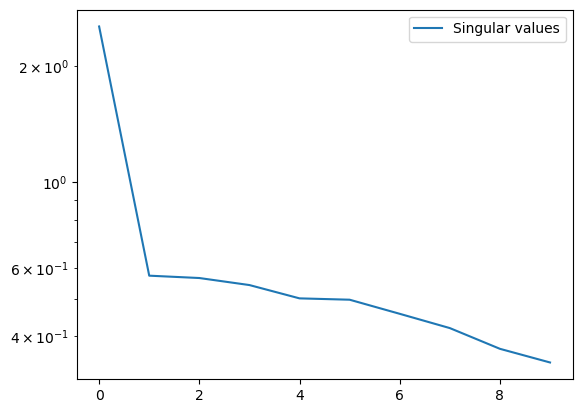

In [21]:
plt.plot(W[2].cpu().numpy(), label="Singular values")
plt.yscale("log")
plt.legend()

In [22]:
c = 10

In [23]:
net = init_model(W[0], W[1], c)
_, _ = eval_model_mnist(net)
print(net)

Loss: 1.40e+00, Accuracy: 86.0%
Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=10, bias=True)
  (2): Identity()
  (3): Linear(in_features=10, out_features=10, bias=True)
)


In [24]:
net = init_model(W[0], W[1], c, activation=torch.nn.SELU())
eval_model_mnist(net)
net

Loss: 1.34e+00, Accuracy: 86.0%


Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=10, bias=True)
  (2): SELU()
  (3): Linear(in_features=10, out_features=10, bias=True)
)

Train: loss=3.403e-01, accuracy=0.90, time=0.00s
Train: loss=2.644e-01, accuracy=0.92, time=0.00s
Train: loss=2.424e-01, accuracy=0.93, time=0.00s


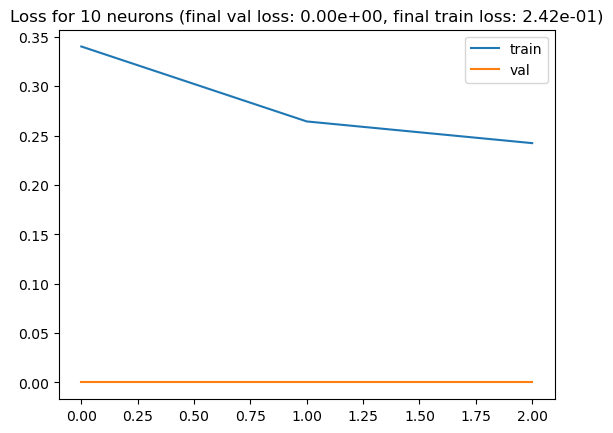

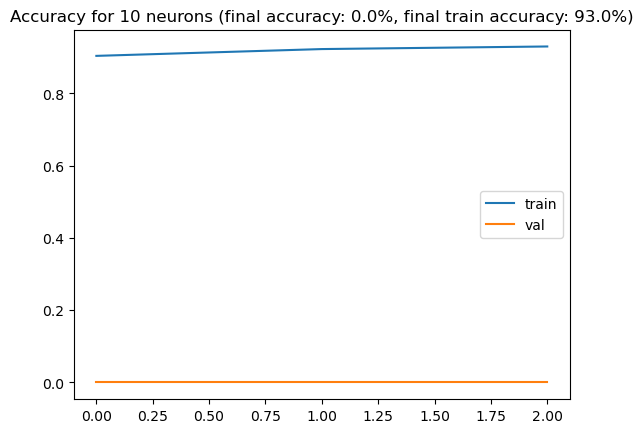

In [25]:
train_and_plot_mnist(net, nb_epoch=3, cut=c)

In [26]:
net = init_model(cut=c, activation=torch.nn.SELU())
eval_model_mnist(net)
net

Loss: 2.37e+00, Accuracy: 11.6%


Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=10, bias=True)
  (2): SELU()
  (3): Linear(in_features=10, out_features=10, bias=True)
)

Train: loss=3.746e-01, accuracy=0.89, time=0.00s
Train: loss=2.681e-01, accuracy=0.92, time=0.00s
Train: loss=2.440e-01, accuracy=0.93, time=0.00s


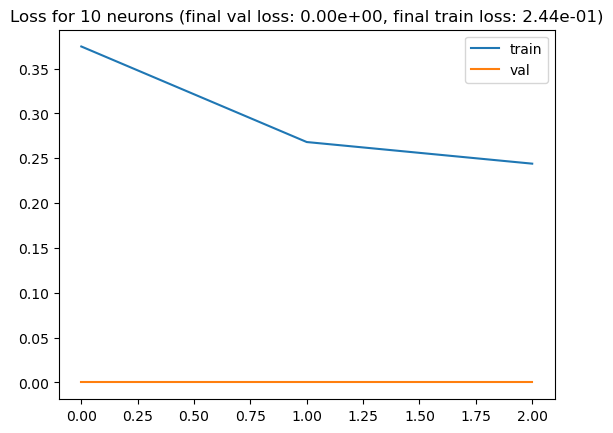

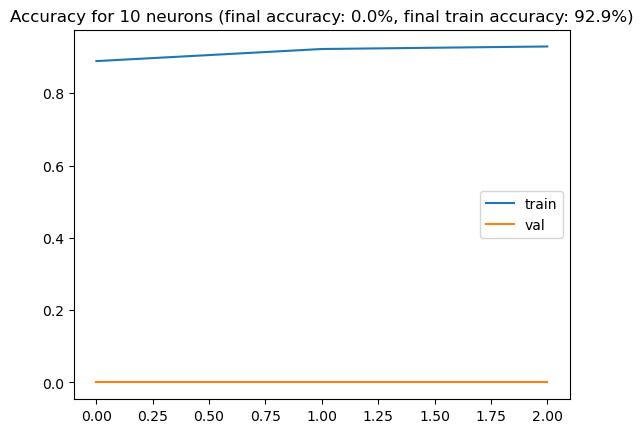

In [27]:
train_and_plot_mnist(net, nb_epoch=3, cut=c)

### C = 5

In [28]:
c = 5

In [29]:
net = init_model(W[0], W[1], c)
eval_model_mnist(net)
net

Loss: 1.77e+00, Accuracy: 58.4%


Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=5, bias=True)
  (2): Identity()
  (3): Linear(in_features=5, out_features=10, bias=True)
)

In [30]:
net = init_model(W[0], W[1], c, activation=torch.nn.SELU())
eval_model_mnist(net)
net

Loss: 1.74e+00, Accuracy: 58.4%


Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=5, bias=True)
  (2): SELU()
  (3): Linear(in_features=5, out_features=10, bias=True)
)

Train: loss=5.108e-01, accuracy=0.85, time=0.00s
Train: loss=4.163e-01, accuracy=0.88, time=0.00s
Train: loss=3.939e-01, accuracy=0.89, time=0.00s


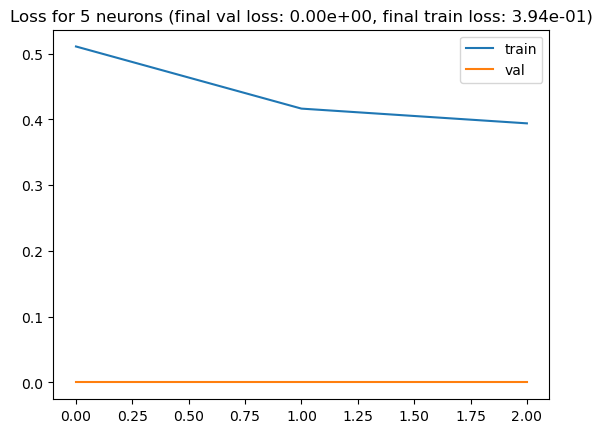

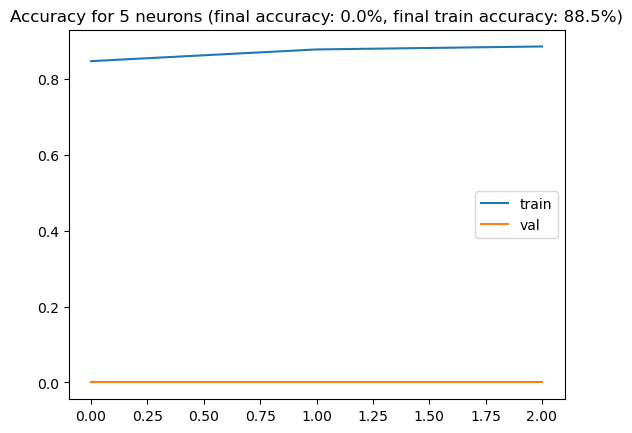

In [31]:
train_and_plot_mnist(net, nb_epoch=3, cut=c)

In [32]:
net = init_model(cut=c, activation=torch.nn.SELU())
eval_model_mnist(net)
net

Loss: 2.39e+00, Accuracy: 12.1%


Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=5, bias=True)
  (2): SELU()
  (3): Linear(in_features=5, out_features=10, bias=True)
)

Train: loss=5.291e-01, accuracy=0.84, time=0.00s
Train: loss=4.289e-01, accuracy=0.87, time=0.00s
Train: loss=4.101e-01, accuracy=0.88, time=0.00s


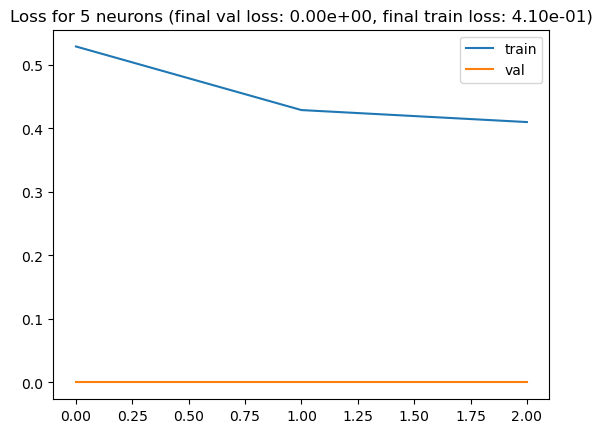

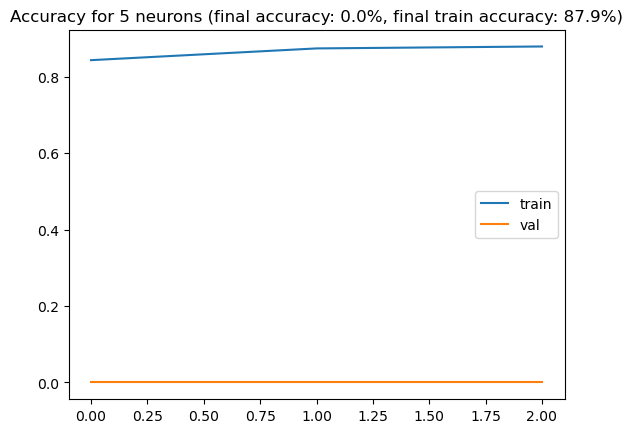

In [33]:
train_and_plot_mnist(net, nb_epoch=3, cut=c)

## Cifar10

In [34]:
DATASET = "cifar10"
K = 10
train_loader, val_loader, test_loader, data_shape = get_dataloaders(DATASET, nb_class=K)
print(
    f"Training data: {len(train_loader)}, "
    f"Validation data: {len(val_loader)}, "
    f"Test data: {len(test_loader)}, "
    f"Input size: {data_shape}"
)

Files already downloaded and verified
Files already downloaded and verified
Training data: 782, Validation data: 0, Test data: 157, Input size: torch.Size([3, 32, 32])


In [35]:
def train_and_plot_cifar10(
    model: torch.nn.Module,
    train_dataloader: torch.utils.data.DataLoader = train_loader,
    val_dataloader: torch.utils.data.DataLoader = test_loader,
    loss_function: torch.nn.Module = torch.nn.CrossEntropyLoss(reduction="mean"),
    nb_epoch: int = 20,
    show: bool = True,
    cut: int = 10,
    device: torch.device = DEVICE,
):
    return train_and_plot(
        model=model,
        train_dataloader=train_dataloader,
        val_dataloader=val_dataloader,
        loss_function=loss_function,
        nb_epoch=nb_epoch,
        show=show,
        cut=cut,
        device=device,
    )


def eval_model_cifar10(
    model: torch.nn.Module, data_loader: torch.utils.data.DataLoader = test_loader
):
    return eval_model(model=model, data_loader=data_loader)

In [36]:
W = low_rank_linear_regression(train_loader, data_shape, K, one_hot=True, device=DEVICE)

  0%|          | 0/782 [00:00<?, ?it/s]

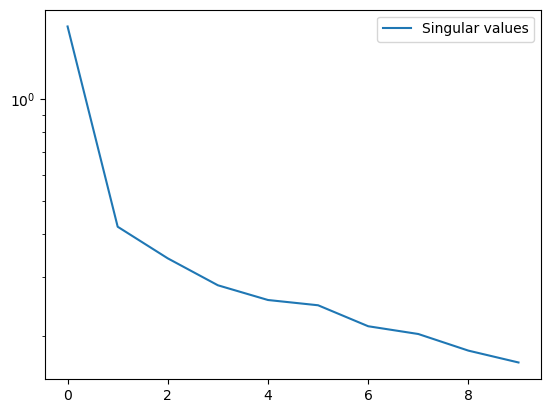

In [37]:
plt.plot(W[2].cpu().numpy(), label="Singular values")
plt.yscale("log")
plt.legend()

In [38]:
c = 10

In [39]:
net = init_model(W[0], W[1], c, input_shape=data_shape, nb_classes=K)
eval_model_cifar10(net)
net

Loss: 2.10e+00, Accuracy: 35.2%


Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=3072, out_features=10, bias=True)
  (2): Identity()
  (3): Linear(in_features=10, out_features=10, bias=True)
)

In [40]:
net = init_model(
    W[0], W[1], c, activation=torch.nn.SELU(), input_shape=data_shape, nb_classes=K
)
eval_model_cifar10(net)
net

Loss: 2.08e+00, Accuracy: 34.8%


Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=3072, out_features=10, bias=True)
  (2): SELU()
  (3): Linear(in_features=10, out_features=10, bias=True)
)

Train: loss=1.777e+00, accuracy=0.37, time=0.00s
Train: loss=1.692e+00, accuracy=0.40, time=0.00s
Train: loss=1.675e+00, accuracy=0.41, time=0.00s
Train: loss=1.652e+00, accuracy=0.42, time=0.00s
Train: loss=1.644e+00, accuracy=0.42, time=0.00s
Train: loss=1.639e+00, accuracy=0.42, time=0.00s
Train: loss=1.635e+00, accuracy=0.42, time=0.00s
Train: loss=1.622e+00, accuracy=0.43, time=0.00s
Train: loss=1.619e+00, accuracy=0.43, time=0.00s
Train: loss=1.611e+00, accuracy=0.43, time=0.00s
Train: loss=1.615e+00, accuracy=0.43, time=0.00s
Train: loss=1.604e+00, accuracy=0.43, time=0.00s
Train: loss=1.602e+00, accuracy=0.44, time=0.00s
Train: loss=1.598e+00, accuracy=0.43, time=0.00s
Train: loss=1.596e+00, accuracy=0.43, time=0.00s
Train: loss=1.591e+00, accuracy=0.44, time=0.00s
Train: loss=1.590e+00, accuracy=0.44, time=0.00s
Train: loss=1.592e+00, accuracy=0.43, time=0.00s
Train: loss=1.588e+00, accuracy=0.44, time=0.00s
Train: loss=1.581e+00, accuracy=0.44, time=0.00s
Train: loss=1.582e+0

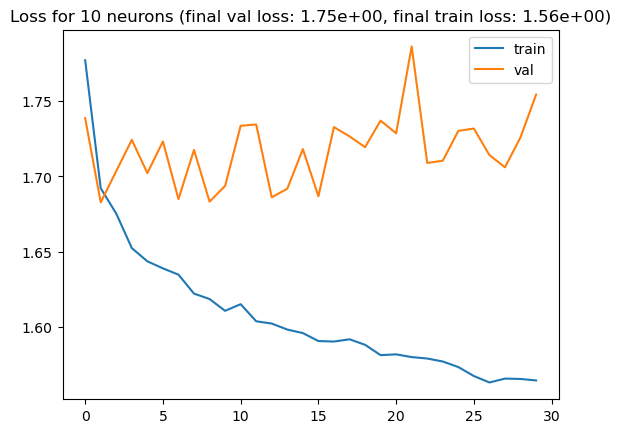

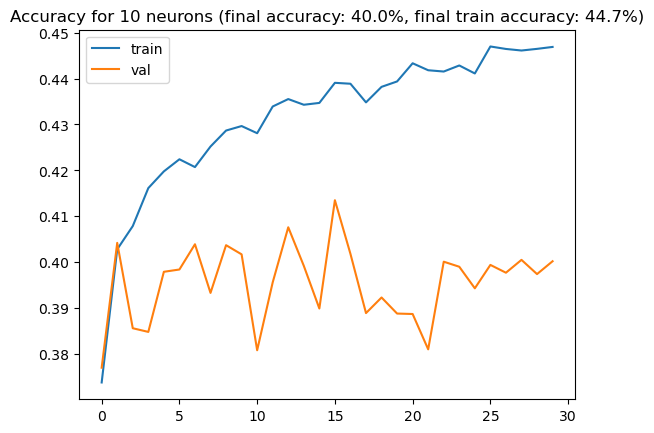

In [41]:
train_and_plot_cifar10(net, nb_epoch=30, cut=c)

In [42]:
net = init_model(
    cut=c, activation=torch.nn.SELU(), input_shape=data_shape, nb_classes=K
)
eval_model_cifar10(net)
net

Loss: 2.40e+00, Accuracy: 10.8%


Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=3072, out_features=10, bias=True)
  (2): SELU()
  (3): Linear(in_features=10, out_features=10, bias=True)
)

Train: loss=1.812e+00, accuracy=0.35, time=0.00s
Train: loss=1.713e+00, accuracy=0.39, time=0.00s
Train: loss=1.682e+00, accuracy=0.40, time=0.00s
Train: loss=1.664e+00, accuracy=0.41, time=0.00s
Train: loss=1.653e+00, accuracy=0.41, time=0.00s
Train: loss=1.642e+00, accuracy=0.41, time=0.00s
Train: loss=1.638e+00, accuracy=0.41, time=0.00s
Train: loss=1.632e+00, accuracy=0.42, time=0.00s
Train: loss=1.623e+00, accuracy=0.42, time=0.00s
Train: loss=1.618e+00, accuracy=0.42, time=0.00s
Train: loss=1.616e+00, accuracy=0.42, time=0.00s
Train: loss=1.610e+00, accuracy=0.42, time=0.00s
Train: loss=1.605e+00, accuracy=0.43, time=0.00s
Train: loss=1.597e+00, accuracy=0.43, time=0.00s
Train: loss=1.603e+00, accuracy=0.43, time=0.00s
Train: loss=1.593e+00, accuracy=0.43, time=0.00s
Train: loss=1.593e+00, accuracy=0.43, time=0.00s
Train: loss=1.591e+00, accuracy=0.43, time=0.00s
Train: loss=1.589e+00, accuracy=0.43, time=0.00s
Train: loss=1.586e+00, accuracy=0.43, time=0.00s
Train: loss=1.583e+0

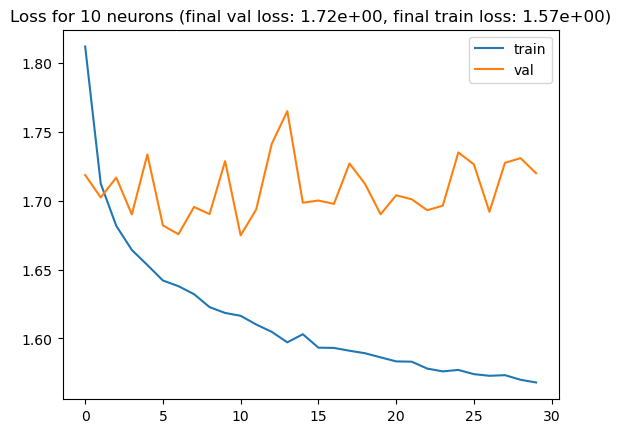

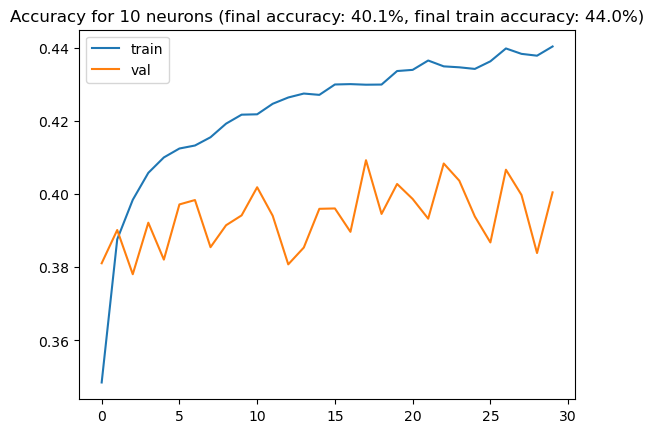

In [43]:
train_and_plot_cifar10(net, nb_epoch=30, cut=c)

In [44]:
net = init_model(
    cut=c, activation=torch.nn.SELU(), input_shape=data_shape, nb_classes=K
)
eval_model_cifar10(net)
net

Loss: 2.36e+00, Accuracy: 8.5%


Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=3072, out_features=10, bias=True)
  (2): SELU()
  (3): Linear(in_features=10, out_features=10, bias=True)
)

Train: loss=1.803e+00, accuracy=0.35, time=0.00s
Train: loss=1.705e+00, accuracy=0.39, time=0.00s
Train: loss=1.681e+00, accuracy=0.40, time=0.00s
Train: loss=1.659e+00, accuracy=0.41, time=0.00s
Train: loss=1.649e+00, accuracy=0.41, time=0.00s
Train: loss=1.647e+00, accuracy=0.41, time=0.00s
Train: loss=1.634e+00, accuracy=0.41, time=0.00s
Train: loss=1.631e+00, accuracy=0.42, time=0.00s
Train: loss=1.622e+00, accuracy=0.42, time=0.00s
Train: loss=1.618e+00, accuracy=0.42, time=0.00s
Train: loss=1.610e+00, accuracy=0.42, time=0.00s
Train: loss=1.610e+00, accuracy=0.42, time=0.00s
Train: loss=1.607e+00, accuracy=0.42, time=0.00s
Train: loss=1.598e+00, accuracy=0.43, time=0.00s
Train: loss=1.597e+00, accuracy=0.43, time=0.00s
Train: loss=1.594e+00, accuracy=0.43, time=0.00s
Train: loss=1.592e+00, accuracy=0.43, time=0.00s
Train: loss=1.587e+00, accuracy=0.43, time=0.00s
Train: loss=1.589e+00, accuracy=0.43, time=0.00s
Train: loss=1.585e+00, accuracy=0.43, time=0.00s
Train: loss=1.584e+0

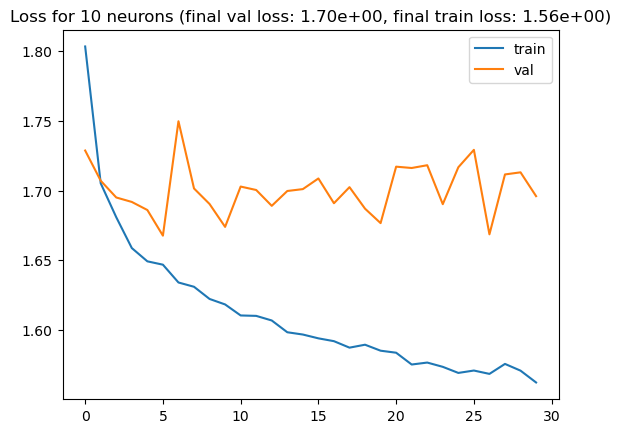

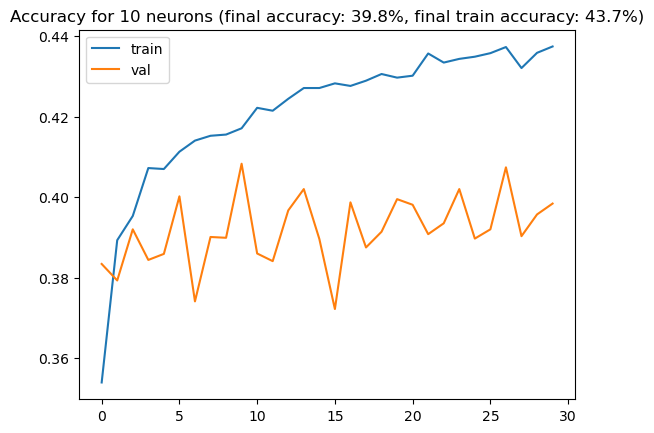

In [45]:
train_and_plot_cifar10(net, nb_epoch=30, cut=c)

### C = 5

In [46]:
c = 5

In [47]:
net = init_model(W[0], W[1], c, input_shape=data_shape, nb_classes=K)
eval_model_cifar10(net)
net

Loss: 2.14e+00, Accuracy: 30.2%


Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=3072, out_features=5, bias=True)
  (2): Identity()
  (3): Linear(in_features=5, out_features=10, bias=True)
)

In [48]:
net = init_model(
    W[0], W[1], c, activation=torch.nn.SELU(), input_shape=data_shape, nb_classes=K
)
eval_model_cifar10(net)
net

Loss: 2.13e+00, Accuracy: 29.6%


Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=3072, out_features=5, bias=True)
  (2): SELU()
  (3): Linear(in_features=5, out_features=10, bias=True)
)

Train: loss=1.856e+00, accuracy=0.33, time=0.00s
Train: loss=1.797e+00, accuracy=0.35, time=0.00s
Train: loss=1.788e+00, accuracy=0.35, time=0.00s
Train: loss=1.781e+00, accuracy=0.35, time=0.00s
Train: loss=1.773e+00, accuracy=0.36, time=0.00s
Train: loss=1.766e+00, accuracy=0.36, time=0.00s
Train: loss=1.766e+00, accuracy=0.36, time=0.00s
Train: loss=1.762e+00, accuracy=0.36, time=0.00s
Train: loss=1.758e+00, accuracy=0.37, time=0.00s
Train: loss=1.763e+00, accuracy=0.36, time=0.00s
Train: loss=1.755e+00, accuracy=0.37, time=0.00s
Train: loss=1.756e+00, accuracy=0.37, time=0.00s
Train: loss=1.754e+00, accuracy=0.37, time=0.00s
Train: loss=1.754e+00, accuracy=0.37, time=0.00s
Train: loss=1.750e+00, accuracy=0.37, time=0.00s
Train: loss=1.748e+00, accuracy=0.37, time=0.00s
Train: loss=1.746e+00, accuracy=0.37, time=0.00s
Train: loss=1.746e+00, accuracy=0.37, time=0.00s
Train: loss=1.747e+00, accuracy=0.37, time=0.00s
Train: loss=1.744e+00, accuracy=0.37, time=0.00s
Train: loss=1.746e+0

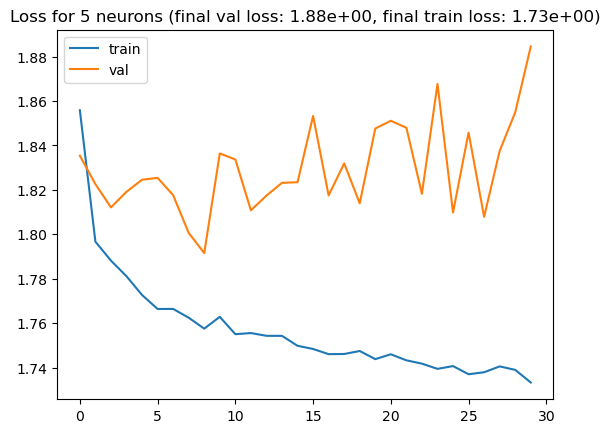

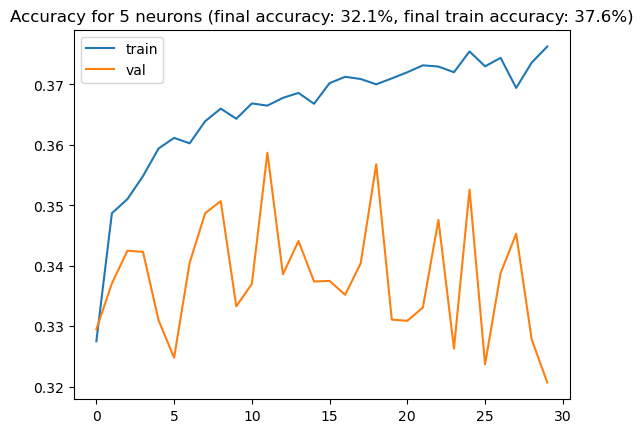

In [49]:
train_and_plot_cifar10(net, nb_epoch=30, cut=c)

In [50]:
net = init_model(
    cut=c, activation=torch.nn.SELU(), input_shape=data_shape, nb_classes=K
)
eval_model_cifar10(net)
net

Loss: 2.35e+00, Accuracy: 12.0%


Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=3072, out_features=5, bias=True)
  (2): SELU()
  (3): Linear(in_features=5, out_features=10, bias=True)
)

Train: loss=1.874e+00, accuracy=0.32, time=0.00s
Train: loss=1.805e+00, accuracy=0.35, time=0.00s
Train: loss=1.794e+00, accuracy=0.35, time=0.00s
Train: loss=1.788e+00, accuracy=0.35, time=0.00s
Train: loss=1.781e+00, accuracy=0.35, time=0.00s
Train: loss=1.776e+00, accuracy=0.35, time=0.00s
Train: loss=1.771e+00, accuracy=0.36, time=0.00s
Train: loss=1.768e+00, accuracy=0.36, time=0.00s
Train: loss=1.762e+00, accuracy=0.36, time=0.00s
Train: loss=1.761e+00, accuracy=0.36, time=0.00s
Train: loss=1.762e+00, accuracy=0.36, time=0.00s
Train: loss=1.759e+00, accuracy=0.36, time=0.00s
Train: loss=1.760e+00, accuracy=0.36, time=0.00s
Train: loss=1.756e+00, accuracy=0.36, time=0.00s
Train: loss=1.756e+00, accuracy=0.36, time=0.00s
Train: loss=1.753e+00, accuracy=0.36, time=0.00s
Train: loss=1.753e+00, accuracy=0.36, time=0.00s
Train: loss=1.754e+00, accuracy=0.36, time=0.00s
Train: loss=1.752e+00, accuracy=0.36, time=0.00s
Train: loss=1.747e+00, accuracy=0.36, time=0.00s
Train: loss=1.747e+0

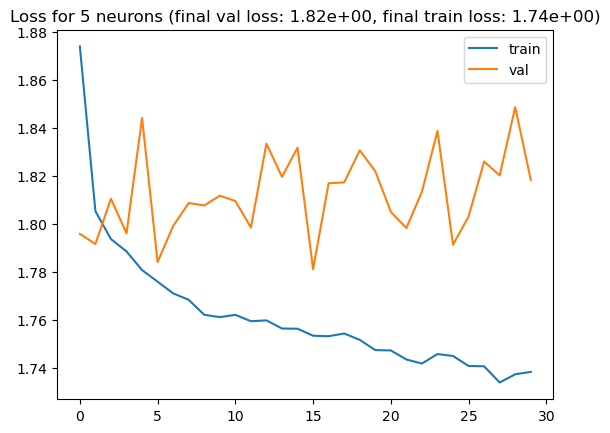

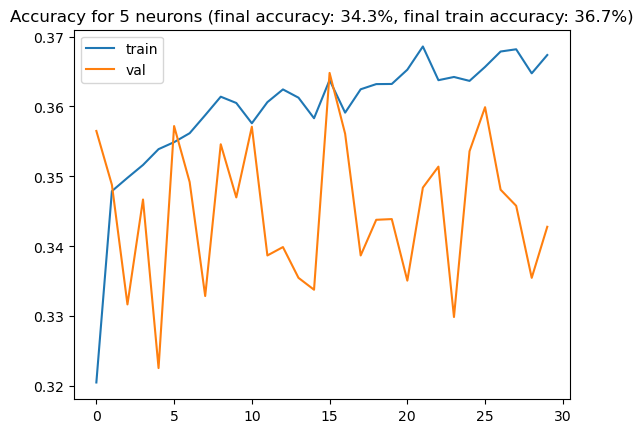

In [51]:
train_and_plot_cifar10(net, nb_epoch=30, cut=c)